# Multi-Task v4 + ANCHORED Corner-Chaining Loss (Q-18 v2)

Followup to [[2026-05-03_v4_chain_collapse]] — the v1 attempt collapsed the keypoint head because the naive `‖adjacent_corner_dist‖` chain objective has a trivial minimum at "all corners coincident." The model exploited that minimum and clustered all 68 corners into a single point in <10 epochs.

**v2 fix: anchor the chain loss against GT chain distances.** Penalize *deviation* from the anatomical chain length, not raw chain length:

```
naive (v1, BROKEN):    L = mean(||pred_BL_n - pred_TL_{n+1}||)         # trivial min at d=0
anchored (v2, FIXED):  L = mean((||pred_dist|| - ||gt_dist||) ** 2)    # min at d=gt (truth)
```

**Why this avoids collapse**: predicting all corners at one point gives `pred_dist = 0` but `gt_dist ≈ 0.02` for adjacent vertebrae (image-relative) → squared error ≈ 4e-4 per pair × 32 valid pairs → loss spikes. The only way to get loss → 0 is to predict chain distances that match the anatomical truth, which requires placing corners at their actual positions.

**What changes vs v4 baseline (only the chain loss)**:
- New `chain_loss` raw term: anchored MSE between predicted and GT adjacent-corner distances
- `MixedLossWithChain` unchanged structurally (Kendall on seg+cobb, fixed `λ_kpt = 1.0`, fixed `λ_chain`)
- **`λ_chain = 0.5`** (down from 1.0 in v1) — margin of safety against numeric scale changes
- Soft-argmax temperature `T = 20` unchanged (sub-pixel recovery on GT heatmaps)

**What changes vs v1 (the collapsed run)**:
- Chain loss formulation: anchored MSE (v2) replaces naive distance (v1)
- `λ_chain`: 0.5 (v2) replaces 1.0 (v1)
- Dataset returns GT corner coords in heatmap-pixel space (`kpt_xy_hm`) for chain anchoring
- Cache root: `multitask_v4_chain_v2/` — isolated from v1

**Acceptance gate** (vs v4 baseline):
- best dice ≥ 0.680 AND **kpt visualization shows distributed corners along the spine** (no collapse)
- best cobb_direct MAE ≤ 5.79° → chain prior was the floor-mover; promote to Q-10 stack
- 5.79° < cobb < 6.69° → modest help → still proceed to Q-10 / Q-01
- cobb ≥ 6.69° → anchored chain prior alone is not enough → ablate `λ_chain` (0.1 / 1.0) or pivot to Q-10

If kpts visualization still shows clustering with the anchored formulation, the failure is more fundamental (soft-argmax gradient pathology, kpt MSE too weak, etc.) — file as second negative result and pivot.

Cache key: `ai/models/checkpoints/multitask_v4_chain_v2/<timestamp>_<hash>/` — config includes `chain_loss_formulation = "anchored_mse_to_gt_distance"` so hash differs from v1.


## 0 · Setup

In [2]:
import math
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from torch.utils.data import DataLoader, Dataset
from torchvision import models

warnings.filterwarnings("ignore", message=".*lerp.*")

In [3]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "params.yaml").exists():
            return p
    raise FileNotFoundError("params.yaml not found above CWD")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PARAMS = yaml.safe_load((REPO_ROOT / "params.yaml").read_text())
SEED = int(PARAMS["data"]["random_seed"])

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    try:
        import torch_directml
        DEVICE = torch_directml.device()
    except ImportError:
        DEVICE = torch.device("cpu")
print(f"repo={REPO_ROOT}\ndevice={DEVICE}\nseed={SEED}")

repo=/home/ortiz/scoliosis
device=privateuseone:0
seed=42


In [4]:
from ai.evaluation.cobb import cobb_from_segmentation_tangent
from ai.preprocessing.keypoints import (
    KEYPOINTS_PER_VERTEBRA,
    TOTAL_KEYPOINTS,
    multiclass_mask_to_keypoints,
)
from ai.preprocessing.segmentation import NUM_SEG_CLASSES
from ai.training.augmentation import (
    affine_transform,
    clahe_like,
    coarse_dropout,
    elastic_deform,
    gamma_correction,
    gaussian_blur,
    gaussian_noise,
    horizontal_flip,
    intensity_jitter,
)
from ai.training.dataset import (
    IMG_H,
    IMG_W,
    TARGET_IDS_V2,
    preprocess_case,
)
from ai.training.losses import seg_loss_fn

NUM_VERT = len(TARGET_IDS_V2)
print(f"size={IMG_H}x{IMG_W}  seg_classes={NUM_SEG_CLASSES}  vertebrae={NUM_VERT}  keypoints={TOTAL_KEYPOINTS}")


size=512x256  seg_classes=18  vertebrae=17  keypoints=68


In [5]:
CLEAN_INDEX_CSV = REPO_ROOT / "data" / "processed" / "audit_v2_corrected" / "clean_index.csv"

def load_clean_index(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"{path} missing — run audit generation first")
    return pd.read_csv(path)

def trainable_rows(df: pd.DataFrame, min_vertebrae: int = 14) -> pd.DataFrame:
    mask = df["status"].isin(["ok", "warn"])
    if "target_vertebrae_count" in df.columns:
        mask = mask & (df["target_vertebrae_count"] >= min_vertebrae)
    return df[mask].reset_index(drop=True)

def split_train_val(df: pd.DataFrame, val_frac: float = 0.2, seed: int = SEED) -> tuple[pd.DataFrame, pd.DataFrame]:
    shuffled = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n_val = max(1, int(round(len(shuffled) * val_frac)))
    return shuffled.iloc[n_val:].reset_index(drop=True), shuffled.iloc[:n_val].reset_index(drop=True)

CLEAN_INDEX = load_clean_index(CLEAN_INDEX_CSV)
TRAINABLE = trainable_rows(CLEAN_INDEX)
TRAIN_DF, VAL_DF = split_train_val(TRAINABLE, val_frac=0.2, seed=SEED)
n_with_cobb = TRAINABLE["cobb_angle_deg"].notna().sum()
print(f"total={len(CLEAN_INDEX)}  trainable={len(TRAINABLE)} (cobb_gt={n_with_cobb})  train={len(TRAIN_DF)}  val={len(VAL_DF)}")

total=250  trainable=249 (cobb_gt=178)  train=199  val=50


## 1 · I/O Contract — Three Targets per Sample

| Tensor | Shape | Dtype | Source | Notes |
|---|---|---|---|---|
| `image` | `(1, 512, 256)` | float32 | grayscale X-ray, normalized to `[0, 1]` | |
| `seg` | `(512, 256)` | int64 | per-pixel class `0..17` | |
| `kpt_heatmap` | `(68, 128, 64)` | float32 | Gaussian blob per corner at H/4 × W/4 | zeros where vertebra missing |
| `kpt_valid` | `(68,)` | bool | mask of finite keypoints | warn cases (14–16 vert) have ≤16 valid groups |
| `cobb` | `()` | float32 | scalar Cobb angle (degrees) | NaN when missing |
| `cobb_valid` | `()` | bool | True if `cobb` is finite | only ~178 / 249 cases |

Heatmaps live at H/4 × W/4 (= 128 × 64) to keep the keypoint output tensor under 10 MB per sample. Argmax + ×4 scaling recovers pixel coordinates.

In [6]:
HEATMAP_DOWNSAMPLE = 4
HM_H = IMG_H // HEATMAP_DOWNSAMPLE  # 128
HM_W = IMG_W // HEATMAP_DOWNSAMPLE  # 64
HEATMAP_SIGMA = 2.0  # gaussian sigma in heatmap-resolution pixels

def render_heatmaps(
    keypoints_xy_full: np.ndarray,
    h: int = HM_H,
    w: int = HM_W,
    downsample: int = HEATMAP_DOWNSAMPLE,
    sigma: float = HEATMAP_SIGMA,
) -> tuple[np.ndarray, np.ndarray]:
    """Return (heatmaps (K,h,w) float32, valid (K,) bool)."""
    k = keypoints_xy_full.shape[0]
    hm = np.zeros((k, h, w), dtype=np.float32)
    valid = np.zeros((k,), dtype=bool)
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
    for i in range(k):
        x_full, y_full = keypoints_xy_full[i]
        if not (np.isfinite(x_full) and np.isfinite(y_full)):
            continue
        cx = x_full / downsample
        cy = y_full / downsample
        hm[i] = np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2.0 * sigma ** 2))
        valid[i] = True
    return hm, valid


def keypoints_from_heatmaps(
    hm: torch.Tensor,
    threshold: float = 0.1,
    upsample: int = HEATMAP_DOWNSAMPLE,
) -> tuple[np.ndarray, np.ndarray]:
    """Argmax peak per channel, scale to full-resolution pixel coords.

    Args:
        hm: (K, h, w) heatmap tensor
    Returns:
        coords: (K, 2) float array of (x, y) in full-resolution pixels (NaN if peak < threshold)
        scores: (K,) peak intensities
    """
    k, h, w = hm.shape
    flat = hm.reshape(k, -1)
    scores, idx = flat.max(dim=1)
    ys = (idx // w).float() * upsample
    xs = (idx % w).float() * upsample
    coords = torch.stack([xs, ys], dim=1).cpu().numpy()
    s = scores.cpu().numpy()
    coords[s < threshold] = np.nan
    return coords, s

In [7]:
sample = TRAINABLE.iloc[0]
case = preprocess_case(sample)
kps_full = case["kps"].numpy()
hm, valid = render_heatmaps(kps_full)
cobb = sample.get("cobb_angle_deg")
print(f"image          {tuple(case['image'].shape)} {case['image'].dtype}")
print(f"seg            {tuple(case['seg'].shape)} {case['seg'].dtype}  classes={sorted(torch.unique(case['seg']).tolist())[:6]}...")
print(f"kps (full px)  {kps_full.shape} finite={int(np.isfinite(kps_full).all(axis=1).sum())}/{TOTAL_KEYPOINTS}")
print(f"heatmaps       {hm.shape}  valid={int(valid.sum())}/{TOTAL_KEYPOINTS}  peak={hm.max():.3f}")
print(f"cobb           {cobb}")

image          (1, 512, 256) torch.float32
seg            (512, 256) torch.int64  classes=[0, 1, 2, 3, 4, 5]...
kps (full px)  (68, 2) finite=68/68
heatmaps       (68, 128, 64)  valid=68/68  peak=0.999
cobb           nan


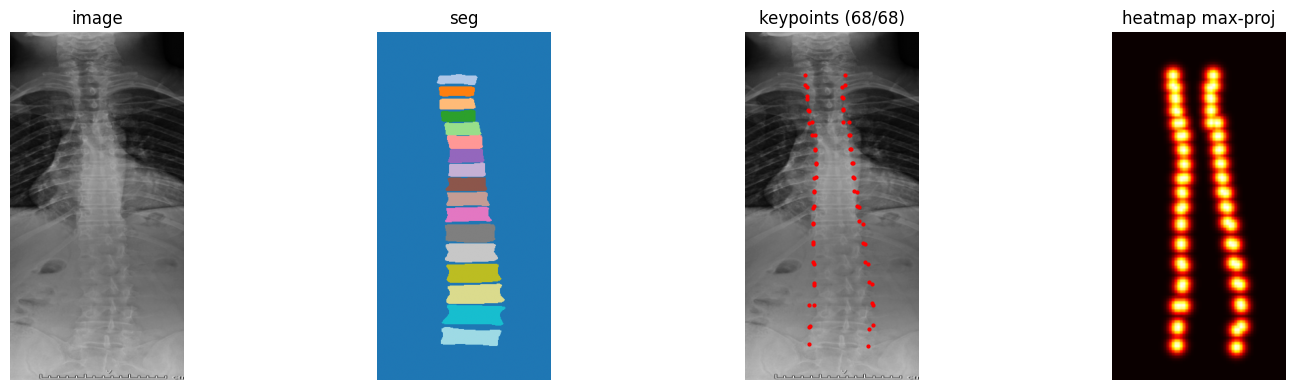

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("image")
axes[1].imshow(case["seg"], cmap="tab20"); axes[1].set_title("seg")
# overlay first 4 keypoints (corners of T1) on image
axes[2].imshow(case["image"].squeeze(0), cmap="gray")
fin = np.isfinite(kps_full).all(axis=1)
axes[2].scatter(kps_full[fin, 0], kps_full[fin, 1], s=4, c="red")
axes[2].set_title(f"keypoints ({int(fin.sum())}/68)")
# combined heatmap (max-projection over channels)
axes[3].imshow(hm.max(axis=0), cmap="hot"); axes[3].set_title("heatmap max-proj")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 1.5 · Cobb-Preserving Augmentation (lifted from v3)


In [9]:
def augment_v5_cobb_aware(image, seg):
    """Same chain as augment_v4 but returns a `cobb_preserved` flag that is
    False when elastic_deform fires (which can change the spinal curve).
    Horizontal flip preserves |Cobb|, so it does NOT mask the Cobb target."""
    cobb_preserved = True
    if torch.rand(1).item() < 0.7:
        image, seg = affine_transform(
            image, seg,
            angle_range=(-15.0, 15.0),
            translate_frac=0.10,
            scale_range=(0.85, 1.15),
        )
    if torch.rand(1).item() < 0.5:
        image, seg = horizontal_flip(image, seg)
    if torch.rand(1).item() < 0.4:
        image, seg = elastic_deform(image, seg, alpha=40.0, sigma=6.0)
        cobb_preserved = False
    if torch.rand(1).item() < 0.5:
        image = intensity_jitter(image, gain_range=(0.7, 1.3), bias_range=(-0.15, 0.15))
    if torch.rand(1).item() < 0.3:
        image = gamma_correction(image)
    if torch.rand(1).item() < 0.3:
        image = gaussian_blur(image)
    if torch.rand(1).item() < 0.2:
        image = clahe_like(image)
    if torch.rand(1).item() < 0.3:
        image = gaussian_noise(image, std_range=(0.0, 0.08))
    if torch.rand(1).item() < 0.25:
        image = coarse_dropout(image, n_patches=12, patch_size=40)
    return image, seg, cobb_preserved


## 2 · Multi-Task Dataset (returns GT corner coords for anchored chain loss)

Same as v4 / v1 but adds **`kpt_xy_hm`** — GT corner coordinates in heatmap-pixel space (1/`HEATMAP_DOWNSAMPLE` of full-res). Used by the anchored chain loss in §5.5. NaN values for missing corners (already produced by `multiclass_mask_to_keypoints`); the chain-loss `kpt_valid` mask handles the NaN-skipping.

The augmentation chain re-extracts keypoints from the (possibly augmented) seg, so `kpt_xy_hm` stays aligned with the augmented sample.


In [10]:
class MultiTaskSpineDataset(Dataset):
    """v2 dataset: returns kpt_xy_hm in addition to v1 fields, for anchored chain loss."""

    def __init__(
        self,
        df: pd.DataFrame,
        augment: bool = False,
        target_ids: tuple[int, ...] = TARGET_IDS_V2,
    ):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.target_ids = target_ids

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, i: int) -> dict[str, torch.Tensor]:
        row = self.df.iloc[i]
        case = preprocess_case(row, target_ids=self.target_ids)
        image, seg = case["image"], case["seg"]

        cobb_preserved = True
        if self.augment:
            image, seg, cobb_preserved = augment_v5_cobb_aware(image, seg)

        # re-extract keypoints from (possibly augmented) seg
        seg_np = seg.numpy().astype(np.uint8)
        raw = np.zeros_like(seg_np)
        for k_idx, raw_id in enumerate(self.target_ids, start=1):
            raw[seg_np == k_idx] = raw_id
        kps_full = multiclass_mask_to_keypoints(raw, target_ids=self.target_ids)  # (68, 2) in full-res px, NaN where missing
        hm, valid = render_heatmaps(kps_full)

        # NEW: GT corner coords in heatmap-pixel space (where soft-argmax outputs live)
        # NaN values preserved; chain loss masks them via kpt_valid
        kps_hm = (kps_full / HEATMAP_DOWNSAMPLE).astype(np.float32)  # (68, 2) in HM px, NaN where missing
        # zero out NaNs so the tensor is well-defined; mask handles validity downstream
        kps_hm = np.where(np.isnan(kps_hm), 0.0, kps_hm)

        cobb_val = row.get("cobb_angle_deg")
        has_gt = pd.notna(cobb_val) and cobb_preserved
        cobb_t = torch.tensor(float(cobb_val) if has_gt else 0.0, dtype=torch.float32)
        cobb_valid = torch.tensor(bool(has_gt))

        return {
            "image": image,
            "seg": seg,
            "kpt_heatmap": torch.from_numpy(hm),
            "kpt_valid": torch.from_numpy(valid),
            "kpt_xy_hm": torch.from_numpy(kps_hm),  # NEW for v2
            "cobb": cobb_t,
            "cobb_valid": cobb_valid,
        }


def multitask_collate(batch: list[dict]) -> dict[str, torch.Tensor]:
    return {k: torch.stack([b[k] for b in batch]) for k in batch[0]}


# sanity check one batch
_ds = MultiTaskSpineDataset(TRAIN_DF.head(4), augment=False)
_b = multitask_collate([_ds[i] for i in range(4)])
for k, v in _b.items():
    print(f'  {k:14s}  {tuple(v.shape)}  {v.dtype}')


  image           (4, 1, 512, 256)  torch.float32
  seg             (4, 512, 256)  torch.int64
  kpt_heatmap     (4, 68, 128, 64)  torch.float32
  kpt_valid       (4, 68)  torch.bool
  kpt_xy_hm       (4, 68, 2)  torch.float32
  cobb            (4,)  torch.float32
  cobb_valid      (4,)  torch.bool


## 3 · MultiTask Architecture

ResNet-34 encoder (ImageNet-pretrained, grayscale stem) shared across three heads:

- **Seg head**  — 1×1 conv on full-resolution decoder features → 18 logits per pixel (identical to `EncoderUNet`)
- **Kpt head**  — 1×1 conv on H/4 decoder features → 68 heatmaps (matches dataset target resolution, no extra upsample)
- **Cobb head** — global average pool on the bottleneck (B, 512, H/32, W/32) → 2-layer MLP → scalar (degrees)

Encoder/decoder topology mirrors `ai/models/architectures/encoder_unet.py`. Decoder features are tapped at two resolutions (H/4 for keypoints, H for seg).

In [11]:
def _conv_block(in_ch: int, out_ch: int) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )


class _Up(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = _conv_block(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        dy = skip.shape[2] - x.shape[2]
        dx = skip.shape[3] - x.shape[3]
        if dy != 0 or dx != 0:
            x = F.pad(x, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        return self.conv(torch.cat([x, skip], dim=1))


class MultiTaskEncoderUNet(nn.Module):
    """Shared ResNet-34 encoder with seg + keypoint + Cobb heads."""

    def __init__(
        self,
        in_ch: int = 1,
        num_seg_classes: int = NUM_SEG_CLASSES,
        num_keypoints: int = TOTAL_KEYPOINTS,
        pretrained: bool = True,
        dropout: float = 0.2,
        cobb_norm: float = 90.0,
    ):
        super().__init__()
        self.cobb_norm = cobb_norm

        weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet34(weights=weights)

        original_conv1 = backbone.conv1
        self.conv1 = nn.Conv2d(in_ch, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained and in_ch == 1:
            self.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)
        elif pretrained and in_ch == 3:
            self.conv1.weight.data = original_conv1.weight.data

        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.up1 = _Up(512, 256, 256)
        self.up2 = _Up(256, 128, 128)
        self.up3 = _Up(128, 64, 64)   # produces (B, 64, H/4, W/4) — keypoint tap
        self.up4 = _Up(64, 64, 64)    # produces (B, 64, H/2, W/2)
        self.final_up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.drop = nn.Dropout2d(dropout)

        # heads
        self.seg_head = nn.Conv2d(64, num_seg_classes, 1)
        self.kpt_head = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_keypoints, 1),
        )
        self.cobb_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

        self._encoder_modules = [
            self.conv1, self.bn1, self.layer1, self.layer2, self.layer3, self.layer4,
        ]
        self._decoder_modules = [
            self.up1, self.up2, self.up3, self.up4, self.final_up, self.drop,
            self.seg_head, self.kpt_head, self.cobb_head,
        ]

    def forward(self, x: torch.Tensor) -> dict[str, torch.Tensor]:
        x0 = self.relu(self.bn1(self.conv1(x)))
        x_pool = self.maxpool(x0)
        s1 = self.layer1(x_pool)
        s2 = self.layer2(s1)
        s3 = self.layer3(s2)
        bridge = self.layer4(s3)  # (B, 512, H/32, W/32) — Cobb tap

        y = self.up1(bridge, s3)
        y = self.up2(y, s2)
        y_q = self.up3(y, s1)              # (B, 64, H/4, W/4) — kpt tap
        y = self.up4(y_q, x0)
        y_full = self.final_up(y)          # (B, 64, H, W)
        y_full = self.drop(y_full)

        seg_logits = self.seg_head(y_full)
        kpt_heatmaps = self.kpt_head(y_q)  # (B, 68, H/4, W/4)
        cobb_norm_pred = self.cobb_head(bridge).squeeze(-1)  # (B,)
        cobb_pred = cobb_norm_pred * self.cobb_norm  # rescale to degrees

        return {
            "seg": seg_logits,
            "kpt": kpt_heatmaps,
            "cobb": cobb_pred,
        }

    def encoder_params(self):
        for m in self._encoder_modules:
            yield from m.parameters()

    def decoder_params(self):
        for m in self._decoder_modules:
            yield from m.parameters()


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


model = MultiTaskEncoderUNet(pretrained=True, dropout=0.2).to(DEVICE)
n_enc = sum(p.numel() for p in model.encoder_params())
n_dec = sum(p.numel() for p in model.decoder_params())
print(f"MultiTaskEncoderUNet total params: {count_params(model):,}")
print(f"  encoder: {n_enc:,}  decoder+heads: {n_dec:,}")

Dropped Escape call with ulEscapeCode : 0x03007703


MultiTaskEncoderUNet total params: 24,501,303
  encoder: 21,278,400  decoder+heads: 3,222,903


## 4 · Forward-Pass Sanity Check

In [12]:
model.eval()
with torch.no_grad():
    out = model(case["image"].unsqueeze(0).to(DEVICE))
for k, v in out.items():
    print(f"  {k:6s}  {tuple(v.shape)}  {v.dtype}")

  seg     (1, 18, 512, 256)  torch.float32
  kpt     (1, 68, 128, 64)  torch.float32
  cobb    (1,)  torch.float32


## 5.5 · Anchored Chain Loss (v2 — collapse-resistant)

**Soft-argmax** turns each `(K, H, W)` heatmap into a `(K, 2)` predicted coordinate via softmax-weighted spatial expectation. Differentiable end-to-end. Temperature `T = 20` tuned on GT-Gaussian heatmaps (median sub-pixel accuracy).

**Anchored chain loss** (v2 formulation): for each adjacent-vertebra pair n → n+1, compute the predicted chain distance and the GT chain distance, then penalize their squared deviation:

$$L_\text{chain} = \frac{1}{|\mathcal{V}|} \sum_{(a,b) \in \mathcal{V}} \left( \|p_a - p_b\|_2 - \|g_a - g_b\|_2 \right)^2$$

where:
- $p_a, p_b$ are predicted corner coords (soft-argmax outputs, image-relative)
- $g_a, g_b$ are GT corner coords from `kpt_xy_hm` (image-relative)
- $\mathcal{V}$ is the set of adjacent corner pairs `(BL_n, TL_{n+1})` and `(BR_n, TR_{n+1})` with both endpoints valid

**Why this anti-collapses**: the trivial "all corners at one point" prediction gives `||p_a - p_b|| = 0`, but `||g_a - g_b|| ≈ 0.02` for adjacent vertebrae → loss = (0.02)² × 32 valid pairs ≈ 0.013 (high penalty per batch). The only way to drive loss to ~0 is for predicted distances to MATCH the anatomical chain — which requires placing corners at their actual positions. This re-aligns chain loss with the kpt MSE objective instead of fighting it.

**DirectML-compatibility** preserved from v1 — vectorized via reshape (B, V, 4, 2) + range-slice indexing.


In [13]:
SOFT_ARGMAX_TEMPERATURE = 20.0  # unchanged from v1: tuned for sub-pixel GT-heatmap recovery
LAMBDA_CHAIN = 0.5              # v2: down from 1.0 in v1; margin of safety against numeric scale changes in the anchored formulation


def soft_argmax_2d(heatmap: torch.Tensor, temperature: float = SOFT_ARGMAX_TEMPERATURE) -> torch.Tensor:
    """DirectML-compatible soft-argmax. Same as v1."""
    b, k, h, w = heatmap.shape
    weights = F.softmax((heatmap * temperature).view(b, k, h * w), dim=-1).view(b, k, h, w)
    grid_y = torch.arange(h, device=heatmap.device, dtype=heatmap.dtype).view(1, 1, h, 1)
    grid_x = torch.arange(w, device=heatmap.device, dtype=heatmap.dtype).view(1, 1, 1, w)
    cy = (weights * grid_y).sum(dim=(2, 3))  # (B, K)
    cx = (weights * grid_x).sum(dim=(2, 3))  # (B, K)
    return torch.stack([cx, cy], dim=-1)


def chain_loss_fn(
    kpt_heatmap: torch.Tensor,
    kpt_xy_hm: torch.Tensor,
    kpt_valid: torch.Tensor,
    num_vert: int = NUM_VERT,
    temperature: float = SOFT_ARGMAX_TEMPERATURE,
) -> torch.Tensor:
    """Anchored chain loss: MSE between predicted and GT adjacent-corner distances.

    Args:
        kpt_heatmap: (B, K, H, W) predicted heatmap logits
        kpt_xy_hm:   (B, K, 2)    GT corner coords in heatmap pixels (NaN-zero-filled)
        kpt_valid:   (B, K)       bool, True where the GT corner exists
    """
    pred_coords = soft_argmax_2d(kpt_heatmap, temperature=temperature) / float(HM_H)  # (B, K, 2) image-relative
    gt_coords = kpt_xy_hm / float(HM_H)                                                # (B, K, 2) image-relative
    b = pred_coords.shape[0]

    # reshape to (B, V, 4, 2) — corner order: TL=0, TR=1, BL=2, BR=3
    pred_v = pred_coords.view(b, num_vert, 4, 2)
    gt_v = gt_coords.view(b, num_vert, 4, 2)
    valid_v = kpt_valid.view(b, num_vert, 4)

    # range-slice the four corner streams (DirectML-safe contiguous narrow ops)
    # left chain: BL of upper -> TL of lower
    BL_up_pred = pred_v[:, :-1, 2:3, :].squeeze(2)
    TL_lo_pred = pred_v[:, 1:,  0:1, :].squeeze(2)
    BL_up_gt   = gt_v[:,   :-1, 2:3, :].squeeze(2)
    TL_lo_gt   = gt_v[:,   1:,  0:1, :].squeeze(2)
    BL_v_up = valid_v[:, :-1, 2:3].squeeze(2)
    TL_v_lo = valid_v[:, 1:,  0:1].squeeze(2)

    # right chain: BR of upper -> TR of lower
    BR_up_pred = pred_v[:, :-1, 3:4, :].squeeze(2)
    TR_lo_pred = pred_v[:, 1:,  1:2, :].squeeze(2)
    BR_up_gt   = gt_v[:,   :-1, 3:4, :].squeeze(2)
    TR_lo_gt   = gt_v[:,   1:,  1:2, :].squeeze(2)
    BR_v_up = valid_v[:, :-1, 3:4].squeeze(2)
    TR_v_lo = valid_v[:, 1:,  1:2].squeeze(2)

    left_mask  = (BL_v_up & TL_v_lo).to(pred_coords.dtype)    # (B, V-1)
    right_mask = (BR_v_up & TR_v_lo).to(pred_coords.dtype)

    left_d_pred  = torch.linalg.norm(BL_up_pred - TL_lo_pred, dim=-1)
    left_d_gt    = torch.linalg.norm(BL_up_gt   - TL_lo_gt,   dim=-1)
    right_d_pred = torch.linalg.norm(BR_up_pred - TR_lo_pred, dim=-1)
    right_d_gt   = torch.linalg.norm(BR_up_gt   - TR_lo_gt,   dim=-1)

    left_err  = (left_d_pred  - left_d_gt)  ** 2
    right_err = (right_d_pred - right_d_gt) ** 2

    total = (left_err * left_mask).sum() + (right_err * right_mask).sum()
    n_valid = left_mask.sum() + right_mask.sum()
    return total / n_valid.clamp(min=1.0)


# sanity check 1: anchored chain loss on GT heatmaps with GT coords should be ~0 (predicted dist == GT dist)
_sample = TRAINABLE.iloc[0]
_case = preprocess_case(_sample)
_kps_full = _case['kps'].numpy()
_hm_gt, _valid_gt = render_heatmaps(_kps_full)
_kps_hm = np.where(np.isnan(_kps_full), 0.0, _kps_full / HEATMAP_DOWNSAMPLE).astype(np.float32)
_hm_t  = torch.from_numpy(_hm_gt).unsqueeze(0)
_kps_t = torch.from_numpy(_kps_hm).unsqueeze(0)
_val_t = torch.from_numpy(_valid_gt).unsqueeze(0)
_anchored_floor = chain_loss_fn(_hm_t, _kps_t, _val_t).item()
print(f'GT-heatmap + GT-coords anchored chain loss (should be near 0): {_anchored_floor:.6f}')

# sanity check 2: collapsing all predictions to one point should give a HIGH loss (anti-collapse)
_collapsed_hm = torch.zeros_like(_hm_t)
_collapsed_hm[..., 50, 30] = 5.0  # all 68 channels peaked at (30, 50) in HM coords
_anchored_collapse = chain_loss_fn(_collapsed_hm, _kps_t, _val_t).item()
print(f'COLLAPSED prediction anchored chain loss (should be HIGH, anti-collapse penalty): {_anchored_collapse:.6f}')
print(f'Ratio collapse/floor: {_anchored_collapse / max(_anchored_floor, 1e-8):.1f}× (target: >> 1)')


GT-heatmap + GT-coords anchored chain loss (should be near 0): 0.000000
COLLAPSED prediction anchored chain loss (should be HIGH, anti-collapse penalty): 0.000065
Ratio collapse/floor: 419.4× (target: >> 1)


## 6 · Multi-Task Loss with Anchored Chain Term

Same `MixedLossWithChain` structure as v1 — chain term held outside Kendall (auxiliary supervision, not a competing task). Only `λ_chain = 0.5` (down from 1.0 in v1) and the anchored formulation differ.


In [14]:
COBB_NORM = 90.0
LAMBDA_KPT = 1.0
LOG_VAR_MIN = -1.5
LOG_VAR_MAX = 4.0


def kpt_loss_fn(pred: torch.Tensor, target: torch.Tensor, valid: torch.Tensor) -> torch.Tensor:
    mask = valid.float().unsqueeze(-1).unsqueeze(-1)
    diff = (pred - target) ** 2 * mask
    denom = mask.sum() * pred.shape[-1] * pred.shape[-2] + 1e-6
    return diff.sum() / denom


def cobb_loss_fn(
    pred_deg: torch.Tensor,
    target_deg: torch.Tensor,
    valid: torch.Tensor,
    norm: float = COBB_NORM,
) -> torch.Tensor:
    if not bool(valid.any()):
        return pred_deg.sum() * 0.0
    p = pred_deg[valid] / norm
    t = target_deg[valid] / norm
    return F.smooth_l1_loss(p, t)


class ClampedKendallLoss(nn.Module):
    def __init__(
        self,
        task_names: tuple[str, ...] = ("seg", "cobb"),
        log_var_min: float = LOG_VAR_MIN,
        log_var_max: float = LOG_VAR_MAX,
    ):
        super().__init__()
        self.task_names = task_names
        self.log_var = nn.Parameter(torch.zeros(len(task_names)))
        self.log_var_min = log_var_min
        self.log_var_max = log_var_max

    def forward(self, raws: dict[str, torch.Tensor]) -> tuple[torch.Tensor, dict[str, float]]:
        clamped = self.log_var.clamp(self.log_var_min, self.log_var_max)
        total = 0.0
        parts: dict[str, float] = {}
        for i, name in enumerate(self.task_names):
            lv = clamped[i]
            li = raws[name]
            term = 0.5 * torch.exp(-lv) * li + 0.5 * lv
            total = total + term
            parts[f"raw_{name}"] = float(li.detach().cpu())
            parts[f"log_var_{name}"] = float(self.log_var[i].detach().cpu())
            parts[f"weight_{name}"] = float((0.5 * torch.exp(-lv)).detach().cpu())
        return total, parts


class MixedLossWithChain(nn.Module):
    """v4 mixed Kendall + fixed kpt + NEW fixed chain (Q-18).

    Chain term is added with fixed λ_chain. Held outside Kendall on purpose — chain loss is
    auxiliary supervision (anatomical prior), not a competing task that should be uncertainty-weighted.
    """

    def __init__(self, kpt_weight: float = LAMBDA_KPT, chain_weight: float = LAMBDA_CHAIN) -> None:
        super().__init__()
        self.kendall = ClampedKendallLoss(("seg", "cobb"))
        self.kpt_weight = kpt_weight
        self.chain_weight = chain_weight

    def forward(self, raws: dict[str, torch.Tensor]) -> tuple[torch.Tensor, dict[str, float]]:
        kendall_total, parts = self.kendall({"seg": raws["seg"], "cobb": raws["cobb"]})
        kpt_term = self.kpt_weight * raws["kpt"]
        chain_term = self.chain_weight * raws["chain"]
        total = kendall_total + kpt_term + chain_term
        parts["raw_kpt"] = float(raws["kpt"].detach().cpu())
        parts["weight_kpt"] = self.kpt_weight
        parts["raw_chain"] = float(raws["chain"].detach().cpu())
        parts["weight_chain"] = self.chain_weight
        parts["loss"] = float(total.detach().cpu())
        return total, parts


def raw_losses_for(out: dict, batch: dict, dev: torch.device) -> dict[str, torch.Tensor]:
    return {
        "seg": seg_loss_fn(out["seg"], batch["seg"].to(dev), NUM_SEG_CLASSES),
        "kpt": kpt_loss_fn(
            out["kpt"],
            batch["kpt_heatmap"].to(dev),
            batch["kpt_valid"].to(dev),
        ),
        "cobb": cobb_loss_fn(
            out["cobb"],
            batch["cobb"].to(dev),
            batch["cobb_valid"].to(dev),
        ),
        "chain": chain_loss_fn(
            out["kpt"],
            batch["kpt_xy_hm"].to(dev),
            batch["kpt_valid"].to(dev),
            temperature=SOFT_ARGMAX_TEMPERATURE,
        ),
    }


## 7 · Training Loop

Same recipe as v4. Cache root = `multitask_v4_chain_v2/` — isolated from v1 (`multitask_v4_chain/`) and from v4 baseline. `run_config()` includes `chain_loss_formulation = "anchored_mse_to_gt_distance"` and `lambda_chain = 0.5` so the hash differs from v1.


In [15]:
import hashlib
import json
from datetime import datetime

CHECKPOINT_ROOT = REPO_ROOT / "ai" / "models" / "checkpoints" / "multitask_v4_chain_v2"
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

NUM_EPOCHS = 150
BATCH_SIZE = 4
LR_ENCODER = 1e-4
LR_DECODER = 1e-3
LR_LOGVAR = 1e-3
WEIGHT_DECAY = 2e-4
WARMUP_EPOCHS = 10
PATIENCE = 25
DROPOUT = 0.2


def run_config() -> dict:
    return {
        "dataset": "v2_corrected",
        "arch": "MultiTaskEncoderUNetV4",
        "encoder": "resnet34",
        "num_seg_classes": NUM_SEG_CLASSES,
        "num_keypoints": TOTAL_KEYPOINTS,
        "heatmap_h": HM_H,
        "heatmap_w": HM_W,
        "heatmap_sigma": HEATMAP_SIGMA,
        "loss": "mixed_clamped_kendall_seg_cobb_plus_fixed_kpt",
        "lambda_kpt": LAMBDA_KPT,
        "chain_loss_formulation": "anchored_mse_to_gt_distance",
        "lambda_chain": LAMBDA_CHAIN,
        "soft_argmax_temperature": SOFT_ARGMAX_TEMPERATURE,
        "log_var_min": LOG_VAR_MIN,
        "log_var_max": LOG_VAR_MAX,
        "cobb_norm": COBB_NORM,
        "augment": "v5_cobb_aware",
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr_encoder": LR_ENCODER,
        "lr_decoder": LR_DECODER,
        "lr_logvar": LR_LOGVAR,
        "weight_decay": WEIGHT_DECAY,
        "warmup_epochs": WARMUP_EPOCHS,
        "patience": PATIENCE,
        "dropout": DROPOUT,
        "seed": SEED,
        "trainable_count": int(len(TRAINABLE)),
        "val_frac": 0.2,
    }


def cfg_hash(cfg: dict) -> str:
    return hashlib.sha256(json.dumps(cfg, sort_keys=True, default=str).encode()).hexdigest()[:8]


def find_cached(cfg: dict) -> Path | None:
    h = cfg_hash(cfg)
    for p in sorted(CHECKPOINT_ROOT.glob(f"*_{h}")):
        if (p / "model.pt").exists():
            return p
    return None


def new_run_dir(cfg: dict) -> Path:
    stamp = datetime.now().strftime("%Y%m%dT%H%M")
    p = CHECKPOINT_ROOT / f"{stamp}_{cfg_hash(cfg)}"
    p.mkdir(parents=True, exist_ok=True)
    return p


In [16]:
def train_step(
    model: nn.Module,
    loss_module: nn.Module,
    batch: dict,
    optimizer: torch.optim.Optimizer,
) -> dict[str, float]:
    out = model(batch["image"].to(DEVICE))
    raws = raw_losses_for(out, batch, DEVICE)
    total, parts = loss_module(raws)
    optimizer.zero_grad()
    total.backward()
    optimizer.step()
    return parts


@torch.no_grad()
def validate(model: nn.Module, loss_module: nn.Module, loader: DataLoader) -> dict[str, float]:
    model.eval()
    accum = {
        "loss": 0.0,
        "raw_seg": 0.0, "raw_kpt": 0.0, "raw_cobb": 0.0, "raw_chain": 0.0,
        "weight_seg": 0.0, "weight_cobb": 0.0,
    }
    inter = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    card = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    cobb_abs_err: list[float] = []
    n_batches = 0
    for batch in loader:
        out = model(batch["image"].to(DEVICE))
        raws = raw_losses_for(out, batch, DEVICE)
        total, parts = loss_module(raws)
        accum["loss"] += float(total.detach().cpu())
        for k in ("raw_seg", "raw_kpt", "raw_cobb", "raw_chain", "weight_seg", "weight_cobb"):
            accum[k] += parts[k]

        pred_mask = out["seg"].argmax(dim=1)
        seg_t = batch["seg"].to(DEVICE)
        for c in range(1, NUM_SEG_CLASSES):
            p, g = (pred_mask == c), (seg_t == c)
            inter[c - 1] += (p & g).sum()
            card[c - 1] += p.sum() + g.sum()

        valid = batch["cobb_valid"]
        if valid.any():
            cobb_pred = out["cobb"].cpu()[valid]
            cobb_true = batch["cobb"][valid]
            cobb_abs_err.extend((cobb_pred - cobb_true).abs().tolist())
        n_batches += 1

    dice_per_cls = (2.0 * inter) / card.clamp(min=1e-6)
    valid_cls = card > 0
    return {
        **{k: v / max(1, n_batches) for k, v in accum.items()},
        "dice": float(dice_per_cls[valid_cls].mean()) if valid_cls.any() else float("nan"),
        "cobb_mae_direct": float(np.mean(cobb_abs_err)) if cobb_abs_err else float("nan"),
    }


In [17]:
cfg = run_config()
_cached = find_cached(cfg)
loss_module = MixedLossWithChain().to(DEVICE)

if _cached is not None:
    state = torch.load(_cached / "model.pt", map_location=DEVICE)
    history_df = pd.read_csv(_cached / "history.csv")
    metrics_cache = json.loads((_cached / "metrics.json").read_text())
    model = MultiTaskEncoderUNet(pretrained=False, dropout=DROPOUT).to(DEVICE)
    model.load_state_dict(state["model"])
    loss_module.load_state_dict(state["loss_module"])
    best_dice = float(metrics_cache["best_val_dice"])
    best_cobb_mae = float(metrics_cache.get("best_val_cobb_mae", float("nan")))
    print(
        f"reused cached run <- {_cached.relative_to(REPO_ROOT)}  "
        f"best_dice={best_dice:.3f}  best_cobb_mae={best_cobb_mae:.2f}°"
    )
else:
    model = MultiTaskEncoderUNet(pretrained=True, dropout=DROPOUT).to(DEVICE)
    print(f"MultiTaskEncoderUNet params: {count_params(model):,}  dropout={DROPOUT}")

    train_loader = DataLoader(
        MultiTaskSpineDataset(TRAIN_DF, augment=True),
        batch_size=BATCH_SIZE, shuffle=True, collate_fn=multitask_collate,
    )
    val_loader = DataLoader(
        MultiTaskSpineDataset(VAL_DF, augment=False),
        batch_size=BATCH_SIZE, shuffle=False, collate_fn=multitask_collate,
    )

    for p in model.encoder_params():
        p.requires_grad = False
    optimizer = torch.optim.Adam([
        {"params": model.decoder_params(), "lr": LR_DECODER, "weight_decay": WEIGHT_DECAY},
        {"params": loss_module.parameters(), "lr": LR_LOGVAR, "weight_decay": 0.0},
    ])
    scheduler = None

    history: list[dict[str, float]] = []
    best_dice = -1.0
    best_cobb_mae = float("inf")
    best_dice_state: dict | None = None
    best_cobb_state: dict | None = None
    best_dice_epoch = -1
    best_cobb_epoch = -1
    no_improve = 0  # tracked against dice for early stopping

    t_start = time.time()
    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()

        if epoch == WARMUP_EPOCHS + 1:
            for p in model.encoder_params():
                p.requires_grad = True
            optimizer = torch.optim.Adam([
                {"params": model.encoder_params(), "lr": LR_ENCODER, "weight_decay": WEIGHT_DECAY},
                {"params": model.decoder_params(), "lr": LR_DECODER, "weight_decay": WEIGHT_DECAY},
                {"params": loss_module.parameters(), "lr": LR_LOGVAR, "weight_decay": 0.0},
            ])
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS
            )
            print(f"  >>> encoder unfrozen at epoch {epoch}")

        model.train()
        train_acc = {"loss": 0.0, "raw_seg": 0.0, "raw_kpt": 0.0, "raw_cobb": 0.0, "raw_chain": 0.0}
        n_steps = 0
        for batch in train_loader:
            parts = train_step(model, loss_module, batch, optimizer)
            train_acc["loss"] += parts["loss"]
            for k in ("raw_seg", "raw_kpt", "raw_cobb", "raw_chain"):
                train_acc[k] += parts[k]
            n_steps += 1
        train_acc = {k: v / max(1, n_steps) for k, v in train_acc.items()}

        val_stats = validate(model, loss_module, val_loader)
        if scheduler is not None:
            scheduler.step()

        n_groups = len(optimizer.param_groups)
        row = {
            "epoch":         epoch,
            "train_loss":    train_acc["loss"],
            "train_seg":     train_acc["raw_seg"],
            "train_kpt":     train_acc["raw_kpt"],
            "train_cobb":    train_acc["raw_cobb"],
            "train_chain":   train_acc["raw_chain"],
            "val_loss":      val_stats["loss"],
            "val_seg":       val_stats["raw_seg"],
            "val_kpt":       val_stats["raw_kpt"],
            "val_cobb":      val_stats["raw_cobb"],
            "val_chain":     val_stats["raw_chain"],
            "w_seg":         val_stats["weight_seg"],
            "w_cobb":        val_stats["weight_cobb"],
            "val_dice":      val_stats["dice"],
            "val_cobb_mae":  val_stats["cobb_mae_direct"],
            "lr_enc":        float(optimizer.param_groups[0]["lr"]) if n_groups > 2 else 0.0,
            "lr_dec":        float(optimizer.param_groups[-2]["lr"]) if n_groups >= 2 else float(optimizer.param_groups[0]["lr"]),
            "sec":           time.time() - t0,
        }
        history.append(row)

        improved_dice = val_stats["dice"] > best_dice
        improved_cobb = (
            not math.isnan(val_stats["cobb_mae_direct"])
            and val_stats["cobb_mae_direct"] < best_cobb_mae
        )
        if improved_dice:
            best_dice = val_stats["dice"]
            best_dice_state = {
                "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                "loss_module": {k: v.detach().cpu().clone() for k, v in loss_module.state_dict().items()},
            }
            best_dice_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1
        if improved_cobb:
            best_cobb_mae = val_stats["cobb_mae_direct"]
            best_cobb_state = {
                "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                "loss_module": {k: v.detach().cpu().clone() for k, v in loss_module.state_dict().items()},
            }
            best_cobb_epoch = epoch

        flags = ""
        if improved_dice:
            flags += " *D"
        if improved_cobb:
            flags += " *C"
        print(
            f"ep {epoch:3d}/{NUM_EPOCHS}  "
            f"tr={row['train_loss']:6.3f} (s={row['train_seg']:.2f} k={row['train_kpt']:.3f} c={row['train_cobb']:.3f} ch={row['train_chain']:.3f})  "
            f"val={row['val_loss']:6.3f}  dice={row['val_dice']:.3f}  cobb={row['val_cobb_mae']:5.1f}°  ch={row['val_chain']:.3f}  "
            f"w[s/c]={row['w_seg']:.2f}/{row['w_cobb']:.2f}  ({row['sec']:.1f}s){flags}"
        )

        if epoch > WARMUP_EPOCHS and no_improve >= PATIENCE:
            print(f"\n  >>> early stop at epoch {epoch}, no dice improvement for {PATIENCE} epochs")
            break

    # restore the best-dice state into the live model (eval cells consume it)
    if best_dice_state is not None:
        model.load_state_dict(best_dice_state["model"])
        loss_module.load_state_dict(best_dice_state["loss_module"])
    history_df = pd.DataFrame(history)

    run_dir = new_run_dir(cfg)
    if best_dice_state is not None:
        torch.save(best_dice_state, run_dir / "model.pt")  # primary ckpt = best dice
    if best_cobb_state is not None:
        torch.save(best_cobb_state, run_dir / "model_best_cobb.pt")
    history_df.to_csv(run_dir / "history.csv", index=False)
    (run_dir / "config.json").write_text(json.dumps(cfg, indent=2, default=str))
    (run_dir / "metrics.json").write_text(json.dumps({
        "best_val_dice": best_dice,
        "best_val_dice_epoch": best_dice_epoch,
        "best_val_cobb_mae": best_cobb_mae if best_cobb_mae != float("inf") else None,
        "best_val_cobb_mae_epoch": best_cobb_epoch,
        "stopped_epoch": int(history_df["epoch"].iloc[-1]),
        "final_log_var": loss_module.kendall.log_var.detach().cpu().tolist(),
    }, indent=2))
    print(
        f"\ntotal time: {time.time() - t_start:.1f}s  "
        f"best dice={best_dice:.3f}@ep{best_dice_epoch}  "
        f"best cobb_mae={best_cobb_mae:.2f}°@ep{best_cobb_epoch}"
    )
    print(f"saved -> {run_dir.relative_to(REPO_ROOT)}")


MultiTaskEncoderUNet params: 24,501,303  dropout=0.2
ep   1/150  tr= 0.800 (s=1.44 k=0.054 c=0.056 ch=0.027)  val= 0.679  dice=0.000  cobb= 17.4°  ch=0.002  w[s/c]=0.48/0.53  (20.4s) *D *C
ep   2/150  tr= 0.630 (s=1.29 k=0.004 c=0.045 ch=0.002)  val= 0.596  dice=0.024  cobb= 17.5°  ch=0.001  w[s/c]=0.46/0.55  (15.5s) *D
ep   3/150  tr= 0.570 (s=1.24 k=0.003 c=0.029 ch=0.002)  val= 0.561  dice=0.011  cobb= 17.7°  ch=0.001  w[s/c]=0.45/0.58  (18.4s)
ep   4/150  tr= 0.518 (s=1.19 k=0.003 c=0.026 ch=0.001)  val= 0.502  dice=0.071  cobb= 22.2°  ch=0.001  w[s/c]=0.45/0.61  (15.6s) *D
ep   5/150  tr= 0.469 (s=1.14 k=0.002 c=0.024 ch=0.001)  val= 0.458  dice=0.091  cobb= 17.1°  ch=0.001  w[s/c]=0.44/0.64  (17.2s) *D *C
ep   6/150  tr= 0.432 (s=1.09 k=0.002 c=0.035 ch=0.001)  val= 0.406  dice=0.130  cobb= 19.6°  ch=0.001  w[s/c]=0.45/0.68  (14.0s) *D
ep   7/150  tr= 0.382 (s=1.05 k=0.002 c=0.026 ch=0.001)  val= 0.384  dice=0.152  cobb= 20.3°  ch=0.001  w[s/c]=0.45/0.71  (14.9s) *D
ep   8/150  t

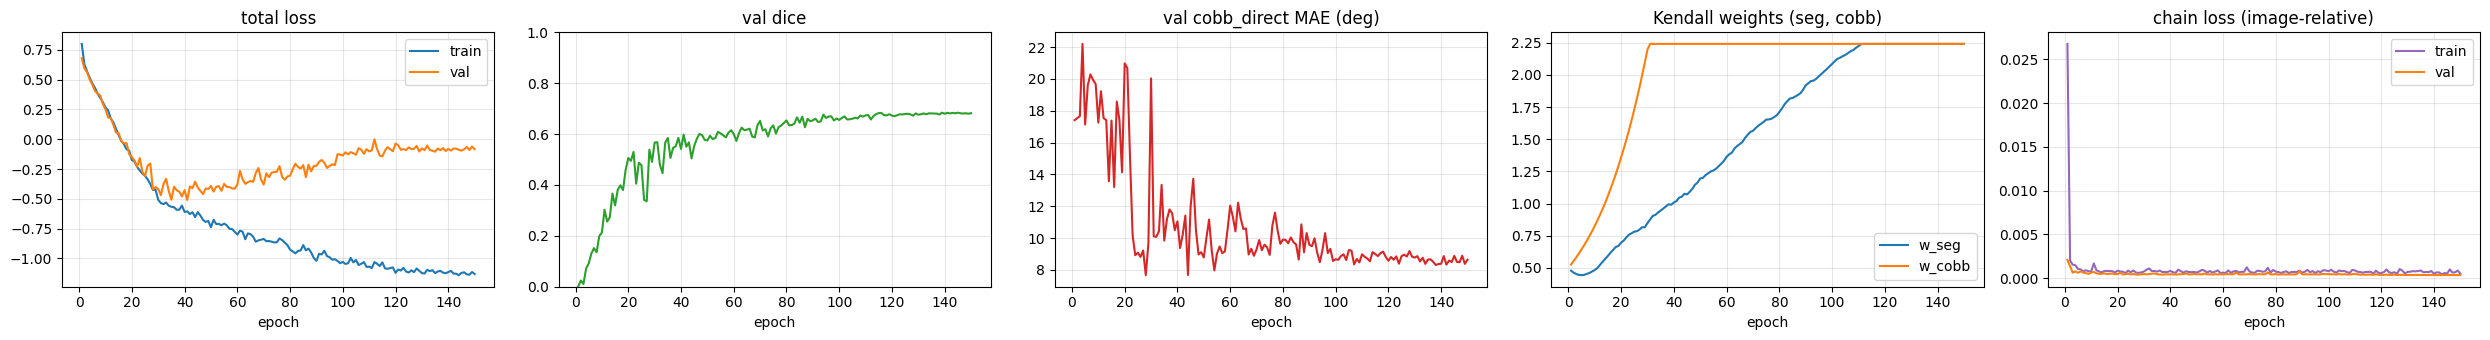

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(25, 3.5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"],   label="val")
axes[0].set(title="total loss", xlabel="epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["val_dice"], color="tab:green")
axes[1].set(title="val dice", xlabel="epoch", ylim=(0.0, 1.0))
axes[1].grid(alpha=0.3)

axes[2].plot(history_df["epoch"], history_df["val_cobb_mae"], color="tab:red")
axes[2].set(title="val cobb_direct MAE (deg)", xlabel="epoch")
axes[2].grid(alpha=0.3)

axes[3].plot(history_df["epoch"], history_df["w_seg"],  label="w_seg")
axes[3].plot(history_df["epoch"], history_df["w_cobb"], label="w_cobb")
axes[3].set(title="Kendall weights (seg, cobb)", xlabel="epoch")
axes[3].legend(); axes[3].grid(alpha=0.3)

axes[4].plot(history_df["epoch"], history_df["train_chain"], label="train", color="tab:purple")
axes[4].plot(history_df["epoch"], history_df["val_chain"],   label="val",   color="tab:orange")
axes[4].set(title="chain loss (image-relative)", xlabel="epoch")
axes[4].legend(); axes[4].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 7 · Evaluation — Three Cobb Estimators

The multi-task model exposes **three independent paths** to a Cobb angle for the same case:

1. **Direct** — `cobb_head` scalar output
2. **From keypoints** — argmax peaks of the keypoint heatmaps → endplate slopes → Cobb
3. **From segmentation** — `seg_head` argmax → existing `cobb_from_segmentation_tangent`

Compare against ground-truth `cobb_angle_deg` to see which path the multi-task encoder produces best, and whether ensembling all three helps.

In [19]:
def cobb_from_keypoints(coords_xy: np.ndarray, num_vert: int = NUM_VERT) -> float:
    """Brute-force pairwise endplate angle.

    coords_xy: (68, 2) float, NaN where keypoint missing. Order: TL, TR, BL, BR per vertebra.
    Returns max absolute difference (deg) between any two endplate slopes.
    """
    angles_top = []
    angles_bot = []
    indices = []
    for v in range(num_vert):
        tl, tr, bl, br = coords_xy[4 * v : 4 * v + 4]
        if np.isfinite(tl).all() and np.isfinite(tr).all():
            dy = tr[1] - tl[1]
            dx = tr[0] - tl[0]
            angles_top.append(math.degrees(math.atan2(dy, dx)))
        else:
            angles_top.append(np.nan)
        if np.isfinite(bl).all() and np.isfinite(br).all():
            dy = br[1] - bl[1]
            dx = br[0] - bl[0]
            angles_bot.append(math.degrees(math.atan2(dy, dx)))
        else:
            angles_bot.append(np.nan)
        indices.append(v)
    a = np.array(angles_top + angles_bot)
    a = a[np.isfinite(a)]
    if len(a) < 2:
        return float("nan")
    diffs = np.abs(a[:, None] - a[None, :])
    return float(diffs.max())


@torch.no_grad()
def evaluate_case(model: nn.Module, row: pd.Series) -> dict:
    case = preprocess_case(row)
    out = model(case["image"].unsqueeze(0).to(DEVICE))
    seg_pred = out["seg"].argmax(dim=1).squeeze(0).cpu()
    kpt_hm = out["kpt"].squeeze(0).cpu()
    cobb_direct = float(out["cobb"].squeeze(0).cpu())

    # dice (mean over present target classes)
    dice_scores: list[float] = []
    for c in range(1, NUM_SEG_CLASSES):
        p, g = (seg_pred == c), (case["seg"] == c)
        denom = p.sum() + g.sum()
        if denom > 0:
            dice_scores.append(float(2.0 * (p & g).sum() / denom))
    dice_mean = float(np.mean(dice_scores)) if dice_scores else float("nan")

    # Cobb from seg pipeline (existing)
    cobb_from_seg = float(cobb_from_segmentation_tangent(seg_pred.numpy()))
    # Cobb from keypoint heatmaps
    coords, _scores = keypoints_from_heatmaps(kpt_hm)
    cobb_from_kpt = cobb_from_keypoints(coords)

    out_row = {
        "dice": dice_mean,
        "cobb_direct": cobb_direct,
        "cobb_from_seg": cobb_from_seg,
        "cobb_from_kpt": cobb_from_kpt,
    }
    gt = row.get("cobb_angle_deg")
    if pd.notna(gt):
        gt = float(gt)
        out_row["cobb_true"] = gt
        for k in ["cobb_direct", "cobb_from_seg", "cobb_from_kpt"]:
            v = out_row[k]
            out_row[f"{k}_abs_err"] = abs(v - gt) if np.isfinite(v) else float("nan")
    return out_row

eval_rows = [evaluate_case(model, r) for _, r in VAL_DF.iterrows()]
eval_df = pd.DataFrame(eval_rows)
print(f"evaluated {len(eval_df)} val cases")
eval_df.head()

evaluated 50 val cases


,dice,cobb_direct,cobb_from_seg,cobb_from_kpt,cobb_true,cobb_direct_abs_err,cobb_from_seg_abs_err,cobb_from_kpt_abs_err
0,0.656545,90.295860,79.066780,90.842524,80.171357,10.124503,1.104577,10.671167
1,0.940913,46.527443,13.125685,27.009196,NaN,NaN,NaN,NaN
2,0.423164,96.555344,119.881487,236.309932,90.000000,6.555344,29.881487,146.309932
3,0.897726,37.248165,9.361168,69.417466,NaN,NaN,NaN,NaN
4,0.880871,40.920788,39.840899,80.537678,37.935438,2.985350,1.905461,42.602240


In [20]:
summary = {
    "n_val":             int(len(eval_df)),
    "mean_dice":         float(eval_df["dice"].mean()),
}
with_gt = eval_df.dropna(subset=["cobb_true"]) if "cobb_true" in eval_df else pd.DataFrame()
if len(with_gt):
    summary["n_with_cobb_gt"] = int(len(with_gt))
    for col in ["cobb_direct", "cobb_from_seg", "cobb_from_kpt"]:
        err = with_gt[f"{col}_abs_err"].dropna()
        if len(err):
            summary[f"{col}_mae"] = float(err.mean())
            summary[f"{col}_n"] = int(len(err))

print("=== Multi-Task v4 + Q-18 ANCHORED corner-chaining (v2) — single 80/20 split ===")
for k, v in summary.items():
    print(f"  {k:30s} {v}")
print()
print("Leaderboard reference (single 80/20):")
print(f"  v4 Kendall (baseline)            dice 0.680   cobb_direct MAE 5.79°  @ ep 54")
print(f"  v4 fixed-weight control          dice 0.683   cobb_direct MAE 6.69°  @ ep 54")
print(f"  v4 + Tier-A (rejected)           dice 0.668   cobb_direct MAE 6.81°  @ ep 59")
print(f"  v4 + naive chain v1 (collapsed)  dice 0.685   cobb_direct MAE 6.95°  @ ep 88  -- KPT HEAD COLLAPSED")
print()
print("Q-18 acceptance gate (chain-loss-only ablation):")
print(f"  no-regression: dice >= 0.680")
print(f"  win:           cobb_direct MAE <= 5.79° -> chain prior was the floor-mover; promote to Q-10 stack")
print(f"  modest help:   5.79 < cobb < 6.69       -> proceed to Q-10 / Q-01 anyway")
print(f"  no help:       cobb >= 6.69             -> ablate λ_chain (try 0.1 / 1.0) or pivot to Q-10")
print(f"  CRITICAL CHECK: kpts visualization in §9 must show distributed corners along spine, NOT a single cluster.")
print(f"  If kpts still collapse with anchored formulation: file second negative result, pivot to Q-10.")

=== Multi-Task v4 + Q-18 ANCHORED corner-chaining (v2) — single 80/20 split ===
  n_val                          50
  mean_dice                      0.6888207152878236
  n_with_cobb_gt                 32
  cobb_direct_mae                8.376395525925073
  cobb_direct_n                  32
  cobb_from_seg_mae              13.369878544619462
  cobb_from_seg_n                32
  cobb_from_kpt_mae              37.80623964088538
  cobb_from_kpt_n                32

Leaderboard reference (single 80/20):
  v4 Kendall (baseline)            dice 0.680   cobb_direct MAE 5.79°  @ ep 54
  v4 fixed-weight control          dice 0.683   cobb_direct MAE 6.69°  @ ep 54
  v4 + Tier-A (rejected)           dice 0.668   cobb_direct MAE 6.81°  @ ep 59
  v4 + naive chain v1 (collapsed)  dice 0.685   cobb_direct MAE 6.95°  @ ep 88  -- KPT HEAD COLLAPSED

Q-18 acceptance gate (chain-loss-only ablation):
  no-regression: dice >= 0.680
  win:           cobb_direct MAE <= 5.79° -> chain prior was the floor-move

## 8 · Qualitative Check

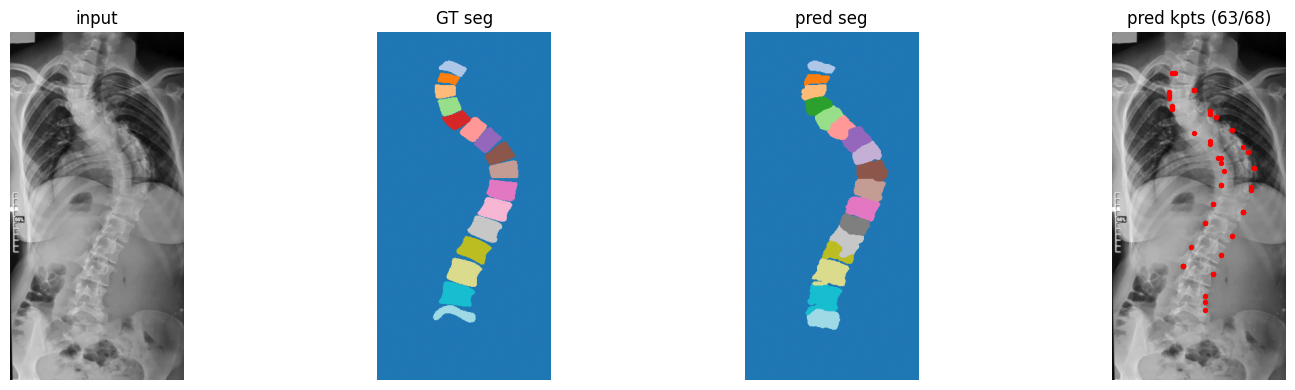

In [21]:
row = VAL_DF.iloc[0]
case = preprocess_case(row)
model.eval()
with torch.no_grad():
    out = model(case["image"].unsqueeze(0).to(DEVICE))
seg_pred = out["seg"].argmax(dim=1).squeeze(0).cpu()
kpt_hm = out["kpt"].squeeze(0).cpu()
coords, scores = keypoints_from_heatmaps(kpt_hm)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("input")
axes[1].imshow(case["seg"], cmap="tab20"); axes[1].set_title("GT seg")
axes[2].imshow(seg_pred, cmap="tab20"); axes[2].set_title("pred seg")
axes[3].imshow(case["image"].squeeze(0), cmap="gray")
fin = np.isfinite(coords).all(axis=1)
axes[3].scatter(coords[fin, 0], coords[fin, 1], s=8, c="red")
axes[3].set_title(f"pred kpts ({int(fin.sum())}/68)")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 9 · Conclusions

TODO after the run: fill in mean dice / cobb_direct MAE / r / sev_acc and the per-cell deltas vs v4.

**FIRST CHECK**: in the qualitative panel, do the predicted keypoints (right-most subplot) form a distributed pattern along the spine (like v4-fixed) or a single cluster (like v1-chain-collapsed)?

Decision tree:
- **Kpts distributed AND Δcobb ≥ 0** → anchored chain prior works as designed → file as positive result + promote to Q-10 / Q-01 stack.
- **Kpts distributed BUT Δcobb < 0** → anchored chain prior does not move cobb on this dataset → file as negative result (chain prior tested, did not help) and pivot to Q-10.
- **Kpts STILL collapsed** → second-order failure (soft-argmax gradient, kpt MSE too weak, etc.) → file as second collapse result, pivot to Q-10. The chain hypothesis is exhausted on this architecture.
- **Kpts mostly distributed but a few stragglers** → tune `λ_chain` (try 0.1 or 1.0) and rerun.

Compare `train_chain` final value against the GT-heatmap floor (~0.0195 in raw distance terms, but in v2 the metric is *squared deviation* ≈ 0 for perfect prediction). If `val_chain` converges to ~1e-5 and kpts look correct, the anchored formulation is doing what it's supposed to.
